In [1]:

# import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
# allow max rows to be displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
# ignore warnings
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, KFold
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline       
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, AdaBoostRegressor, GradientBoostingRegressor
import numpy as np
from cubist import Cubist
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from hyperopt.pyll import scope
pd.set_option('display.max_rows', 150)
import pickle # for saving and loading models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose, MSTL
from sklearn.tree import DecisionTreeRegressor

from peshbeen.models import (ml_forecaster, ml_bidirect_forecaster, VARModel, MsHmmRegression, MsHmmVar)
from peshbeen.model_selection import (cross_validate,  mv_cross_validate,
                                      cv_tune, mv_cv_tune, prob_param_forecasts,
                                      tune_ets, tune_sarima, ParametricTimeSeriesSplit,
                                      forward_feature_selection, backward_feature_selection,
                                      mv_forward_feature_selection, mv_backward_feature_selection,
                                      hmm_forward_feature_selection, hmm_backward_feature_selection,
                                      hmm_mv_forward_feature_selection, hmm_mv_backward_feature_selection,
                                      hmm_cross_validate, hmm_mv_cross_validate, cv_lag_tune, 
                                      cv_hmm_lag_tune)
from peshbeen.statplots import (plot_ccf, plot_PACF_ACF)
from peshbeen.stattools import (unit_root_test, cross_autocorrelation,
                                lr_trend_model, forecast_trend, pacf_strength, ccf_strength)
from peshbeen.transformations import (fourier_terms, rolling_quantile,
                        rolling_mean, rolling_std, expanding_mean, expanding_std,
                        expanding_quantile, expanding_ets, box_cox_transform,
                        back_box_cox_transform,undiff_ts, seasonal_diff, invert_seasonal_diff,
                        nzInterval, zeroCumulative, kfold_target_encoder, target_encoder_for_test)
from peshbeen.metrics import (MAPE, MASE, MSE, MAE, RMSE, SMAPE, CFE, CFE_ABS, WMAPE, SRMSE, RMSSE, SMAE)
from peshbeen.prob_forecast import (ml_prob_forecasts, var_prob_forecasts, hmm_prob_forecasts, ets_prob_forecasts, arima_prob_forecasts, naive_prob_forecasts)
from sktime.transformations.series.boxcox import BoxCoxTransformer
sns.set_context("talk")

In [15]:
occup = pd.read_excel('data/occup_train_clean.xlsx', index_col=0)
occup["day_of_week"] = occup.index.day_name()
occup["month"] = occup.index.month_name()
cat_cols = ["day_of_week", "month", "is_holiday"]
cat_col_f = ["day_of_week", "is_holiday"]

In [16]:
hmm_params = {'blake': {'best_states': 2, 'best_lag': 2, 'best_k': 1},
 'mulberry': {'best_states': 2, 'best_lag': 3, 'best_k': 1},
 'juniper': {'best_states': 2, 'best_lag': 3, 'best_k': 1},
 'magnolia': {'best_states': 6, 'best_lag': 3, 'best_k': 2},
 'clare': {'best_states': 2, 'best_lag': 3, 'best_k': 1},
 'anderson': {'best_states': 2, 'best_lag': 3, 'best_k': 1},
 'other': {'best_states': 2, 'best_lag': 2, 'best_k': 2}}

def data_prep_f(ward, fourier_k):
    ward_train = occup[[ward, "time"]+cat_col_f]
    ft = fourier_terms(start_end_index=(ward_train.index.min(), ward_train.index.max()),
                period=365.25, num_terms=fourier_k)
    return ward_train.merge(ft, left_index=True, right_index=True, how="left")


In [22]:
ward_df= data_prep_f("blake", 1)

train = ward_df.iloc[:-3*84]
test = ward_df.iloc[-3*84:-2*84]
col = "blake"

In [23]:
hm_model_ = MsHmmRegression(n_components=2, target_col=col, cat_variables=cat_col_f, lags=2,
                            random_state=42, n_iter=300, tol=1e-2, ridge=0, verbose=False)
# fit_df = df_[:-360]
hm_model_.fit_em(train)

np.float64(360.66690918204046)

In [ ]:
# # Save to file
# with open('exp_results/hm_model_.pkl', 'wb') as f:
#     pickle.dump(hm_model_, f)# 

# Load from file
with open('exp_results/hm_model_.pkl', 'rb') as f:
    hm_model_ = pickle.load(f)

In [25]:
point_forecasts = hm_model_.forecast(H=84, exog=test.drop(columns=[col]))

## Probabilistic forecast flow

In [26]:
hmm_prob = hmm_prob_forecasts(model=hm_model_, n_calibration=360, H=84, sliding_window=1, n_iter=100, verbose=False)
hmm_prob.calibrate(train)

In [ ]:
# # Save to file
# with open('exp_results/hmm_prob.pkl', 'wb') as f:
#     pickle.dump(hmm_prob, f)# 

# Load from file
with open('exp_results/hmm_prob.pkl', 'rb') as f:
    hmm_prob = pickle.load(f)

In [28]:
boost = hmm_prob.simulate_correlated_forecasts(train, samples=1000, future_exog=test.drop(columns=[col]))

In [29]:
prob_forecasts = boost.correlated_forecasts

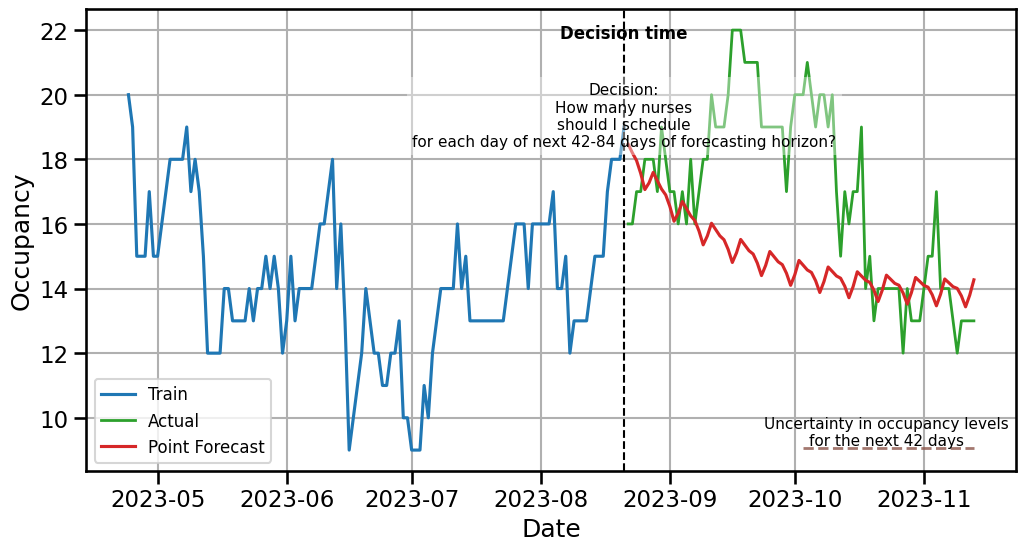

In [30]:
## Generate point forecasts
## Generate probabilistic forecasts
from datetime import timedelta


scenarios_hmm = np.array(prob_forecasts)

## plot scenarios agains train and test
plt.figure(figsize=(12, 6))
plt.plot(train[col].index[-120:], train[col][-120:], label='Train', color='C0')
plt.plot(test.index, test[col], label='Actual', color='C2', linewidth=2, alpha=1)
plt.plot(test.index, point_forecasts, label='Point Forecast', color='C3')
# Define decision time (start of forecast horizon)
decision_time = test.index[0]+ timedelta(days=-1)  # first day of test/forecast period
# for i in range(scenarios_hmm.shape[0]-1):
#     plt.plot(test.index, scenarios_hmm[i], color='C7', alpha=0.1)
# plt.plot(test.index, scenarios_hmm[-1], color='C7', alpha=0.1, label ='All Scenarios (1000)')

# 1. Vertical dashed line
plt.axvline(decision_time, color='black', linestyle='--', linewidth=1.5)

# 2. "Decision time" label at top
plt.text(
    decision_time,
    plt.ylim()[1] * 0.98,
    "Decision time",
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    color='black'
)

# 3. Explanation text box
plt.text(
    decision_time,
    plt.ylim()[1] * 0.90,
    "Decision:\nHow many nurses\nshould I schedule\nfor each day of next 42-84 days of forecasting horizon?",
    ha='center',
    va='top',
    fontsize=11,
    color='black',
    bbox=dict(facecolor='white', alpha=0.4, edgecolor='none')
)


# Choose a low y-level automatically (5% above bottom of plot)
hline_y = plt.ylim()[0] + 0.05 * (plt.ylim()[1] - plt.ylim()[0])

# Horizontal line spanning forecasting period
plt.hlines(
    y=hline_y,
    xmin=test.index[42],
    xmax=test.index[-1],
    color='C5',
    linestyle='--',
    linewidth=2,
    alpha=0.8
)

# Label next to the horizontal line
plt.text(
    test.index[62],
    hline_y,
    "Uncertainty in occupancy levels\nfor the next 42 days",
    ha='center',
    va='bottom',
    fontsize=11,
    color='black'
)


plt.ylabel('Occupancy')
plt.xlabel('Date')
plt.grid(True)
plt.legend(fontsize=12)
plt.show()


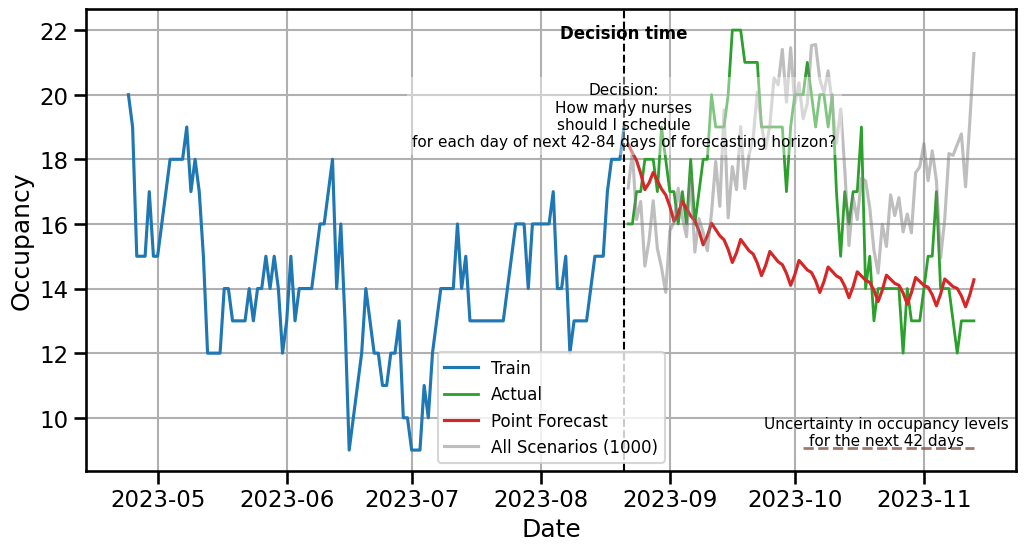

In [31]:
## Generate point forecasts
## Generate probabilistic forecasts
from datetime import timedelta


scenarios_hmm = np.array(prob_forecasts)

## plot scenarios agains train and test
plt.figure(figsize=(12, 6))
plt.plot(train[col].index[-120:], train[col][-120:], label='Train', color='C0')
plt.plot(test.index, test[col], label='Actual', color='C2', linewidth=2, alpha=1)
plt.plot(test.index, point_forecasts, label='Point Forecast', color='C3')
# Define decision time (start of forecast horizon)
decision_time = test.index[0]+ timedelta(days=-1)  # first day of test/forecast period
# for i in range(scenarios_hmm[0:3].shape[0]-1):
#     plt.plot(test.index, scenarios_hmm[i], color='C7', alpha=0.5)
plt.plot(test.index, scenarios_hmm[-1], color='C7', alpha=0.5, label ='All Scenarios (1000)')

# 1. Vertical dashed line
plt.axvline(decision_time, color='black', linestyle='--', linewidth=1.5)

# 2. "Decision time" label at top
plt.text(
    decision_time,
    plt.ylim()[1] * 0.98,
    "Decision time",
    ha='center',
    va='top',
    fontsize=12,
    fontweight='bold',
    color='black'
)

# 3. Explanation text box
plt.text(
    decision_time,
    plt.ylim()[1] * 0.90,
    "Decision:\nHow many nurses\nshould I schedule\nfor each day of next 42-84 days of forecasting horizon?",
    ha='center',
    va='top',
    fontsize=11,
    color='black',
    bbox=dict(facecolor='white', alpha=0.4, edgecolor='none')
)


# Choose a low y-level automatically (5% above bottom of plot)
hline_y = plt.ylim()[0] + 0.05 * (plt.ylim()[1] - plt.ylim()[0])

# Horizontal line spanning forecasting period
plt.hlines(
    y=hline_y,
    xmin=test.index[42],
    xmax=test.index[-1],
    color='C5',
    linestyle='--',
    linewidth=2,
    alpha=0.8
)

# Label next to the horizontal line
plt.text(
    test.index[62],
    hline_y,
    "Uncertainty in occupancy levels\nfor the next 42 days",
    ha='center',
    va='bottom',
    fontsize=11,
    color='black'
)


plt.ylabel('Occupancy')
plt.xlabel('Date')
plt.grid(True)
plt.legend(fontsize=12)
plt.show()


## tables

In [4]:
from great_tables import *

In [ ]:
f_metrics = pd.read_csv("tables/model_ward_sgain_forecasts.csv")

In [15]:
f_metrics.replace({"model": {"PermEntropy": ""}}, inplace=True)

In [16]:
f_metrics

,model,Ward A,Ward B,Ward C,Ward D,Ward E,Ward F,Ward G,overall,metric
0,AR-MSR,3.373633,4.947921,3.260366,3.910015,2.800352,3.782174,2.105290,3.454250,RMSE
1,LASSO,3.793185,5.341442,4.075063,2.318951,3.067318,3.685791,2.084345,3.480871,RMSE
2,LR,3.623391,5.664509,3.700904,2.199278,3.335767,3.983707,2.080061,3.512517,RMSE
3,RF,3.956461,5.071211,4.382106,2.639701,2.867912,4.090270,2.098558,3.586603,RMSE
4,ETS,3.698820,5.486072,3.888890,2.606520,3.602168,3.948612,2.048124,3.611315,RMSE
5,TimeGPT,4.095112,5.507926,3.779924,2.758942,3.407333,3.660007,2.513029,3.674610,RMSE
6,ARIMA,3.662656,5.729906,4.063827,2.463221,3.730140,3.975073,2.198374,3.689028,RMSE
7,NAIVE,4.260987,5.399300,3.892615,2.899999,3.448369,3.706992,2.580958,3.741317,RMSE
8,XGB,4.224786,5.253307,5.149105,2.571125,3.643394,3.943408,2.011702,3.828118,RMSE
9,LGB,3.984276,5.500140,4.400395,4.086323,3.289454,3.862070,1.999413,3.874582,RMSE


In [17]:
f_metrics = pd.read_csv("tables/model_ward_sgain_forecasts.csv")
group_map = {
    "RMSE": "Point Forecast (RMSE)",
    "Pinball": "Probabilistic (Pinball Loss)",
    "PermEntropy": "Permutation Entropy",
    "STO": "Average Understaffed Number of Patients",
    "VSS": "Value of Stochastic Solution"
}

f_metrics_view = f_metrics.assign(metric=f_metrics["metric"].replace(group_map))

GT(f_metrics_view).tab_stub(groupname_col="metric").tab_style(
    style=style.fill(color="#FBFAF4"),
    locations=loc.body()
).tab_style(
    style=style.fill(color="#20808D"),
    locations=loc.column_header()
).tab_style(
    style=style.text(color="#FBFAF4", weight="bold"),
    locations=loc.column_labels()
).tab_style(
    # Targeting the row group labels specifically
    style=[
        style.fill(color="#20808D"), 
        style.text(color="#FBFAF4", weight="bold")
    ],
    locations=loc.row_groups()
).tab_style(
        style=style.text(size="38px", weight="bold"),
        locations=loc.column_labels()
    ).tab_style(
        style=style.text(size="36px"),
        locations=loc.body()
    )

GT(_tbl_data=                    model       Ward A       Ward B       Ward C      Ward D  \
0                  AR-MSR     3.373633     4.947921     3.260366    3.910015   
1                   LASSO     3.793185     5.341442     4.075063    2.318951   
2                      LR     3.623391     5.664509     3.700904    2.199278   
3                      RF     3.956461     5.071211     4.382106    2.639701   
4                     ETS     3.698820     5.486072     3.888890    2.606520   
5                 TimeGPT     4.095112     5.507926     3.779924    2.758942   
6                   ARIMA     3.662656     5.729906     4.063827    2.463221   
7                   NAIVE     4.260987     5.399300     3.892615    2.899999   
8                     XGB     4.224786     5.253307     5.149105    2.571125   
9                     LGB     3.984276     5.500140     4.400395    4.086323   
10                 AR-MSR     1.045588     1.525511     0.964952    0.868996   
11                     LR     1.012719     1.498275     0.963025    0.968045   
12                  LASSO     1.136555     1.606141     1.058391    0.912206   
13                     RF     1.249672     1.640816     1.221365    0.916781   
14                    XGB     1.226932     1.677229     1.325663    0.813778   
15                    ETS     1.245543     1.806563     1.107668    0.942603   
16                  NAIVE     1.383129     1.746438     1.221968    0.965408   
17                  ARIMA     1.163442     1.866146     1.277825    1.000289   
18                    LGB     1.186391     1.833974     1.185235    1.414645   
19                TimeGPT     1.448103     1.955222     1.334803    0.976975   
20            PermEntropy     0.760015     0.723240     0.712319    0.657460   
21                 AR-MSR     0.115079     1.617460     0.422222    0.010317   
22                     LR     0.214286     1.712698     0.512698    0.003968   
23                  LASSO     0.429365     1.565873     0.938889    0.009524   
24                  ARIMA     0.731746     1.737302     0.352381    0.015873   
25                    ETS     0.270635     1.139683     0.681746    0.008730   
26                     RF     0.442063     1.718254     1.230159    0.068254   
27                  NAIVE     1.136508     1.582540     0.409524    0.108730   
28                    XGB     0.595238     1.227778     1.391270    0.024603   
29                    LGB     0.557143     1.619048     1.284921    0.013492   
30  AR-MSR-PointForecasts     1.165873     3.584127     1.342063    0.138889   
31                 AR-MSR   833.571429  1333.650794   836.190476  657.698413   
32                  LASSO   883.253968  1319.126984   931.825397  676.349206   
33                     LR   849.047619  1340.476190   850.634921  739.603175   
34                    ETS   858.968254  1261.428571   883.571429  650.079365   
35                     RF   883.095238  1329.761905   987.777778  653.968254   
36                    XGB   910.476190  1262.936508  1017.380952  633.253968   
37                  ARIMA   932.698413  1398.968254   909.206349  699.841270   
38                  NAIVE  1041.746032  1376.666667   903.174603  661.190476   
39                    LGB   899.047619  1353.968254  1005.476190  766.428571   
40  AR-MSR-PointForecasts  1022.619048  1746.984127  1006.746032  613.095238   

        Ward E      Ward F      Ward G      overall  \
0     2.800352    3.782174    2.105290     3.454250   
1     3.067318    3.685791    2.084345     3.480871   
2     3.335767    3.983707    2.080061     3.512517   
3     2.867912    4.090270    2.098558     3.586603   
4     3.602168    3.948612    2.048124     3.611315   
5     3.407333    3.660007    2.513029     3.674610   
6     3.730140    3.975073    2.198374     3.689028   
7     3.448369    3.706992    2.580958     3.741317   
8     3.643394    3.943408    2.011702     3.828118   
9     3.289454    3.862070    1.999413     3.874582   
10    0.871215    1.2